# Figure 4.3d

# Figure 4.3a – Heatmaps for representative phase-diagram points

# Figure 4.3b — Performance vs alpha (continuous)

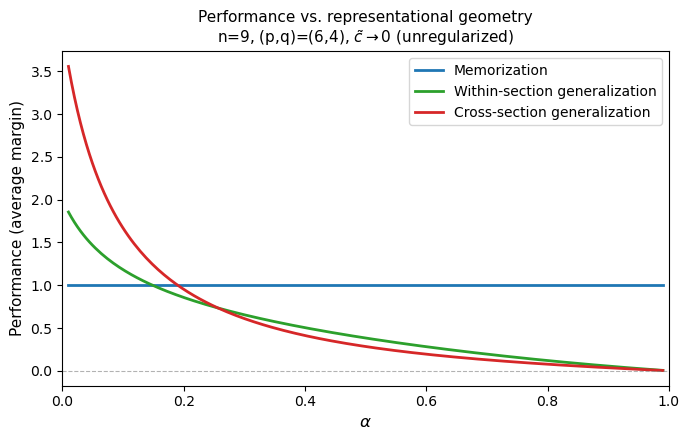

In [77]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d
    # alpha = 1 - 2*(k_o - k_d)/(k_s - k_d), so k_o = (1-alpha)/2 * delta_s + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: average margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.mean(margins)

    # Within-section generalization: average margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.mean(margins)

    # Cross-section generalization: average margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.mean(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (average margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b.pdf", bbox_inches="tight")

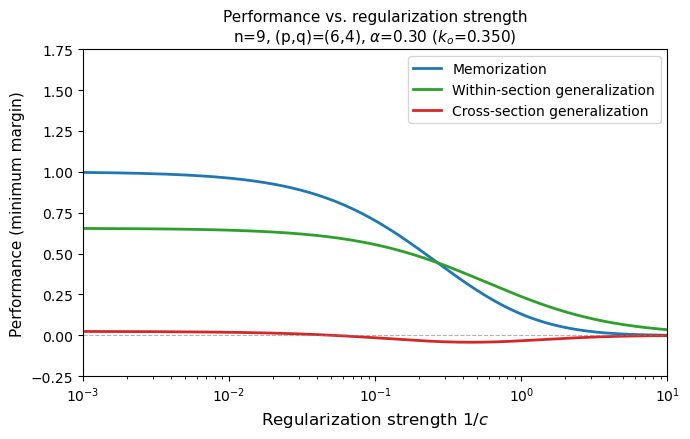

In [74]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0

# Representational geometry held fixed; sweep regularization strength 1/c
alpha_fixed = 0.3
k_o = (1 - alpha_fixed) / 2 * (k_s - k_d) + k_d

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep regularization strength 1/c ───────────────────────────────────────
# Small 1/c  ≈ unregularized; large 1/c ≈ strongly regularized.
c_inv_vals = np.logspace(-3, 1, 200)

mem_perf = np.zeros(len(c_inv_vals))
within_perf = np.zeros(len(c_inv_vals))
cross_perf = np.zeros(len(c_inv_vals))

for idx, c_inv in enumerate(c_inv_vals):
    c_reg_cur = 1.0 / c_inv

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg_cur)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(c_inv_vals, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(c_inv_vals, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(c_inv_vals, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel(r'Regularization strength $1/c$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. regularization strength\nn={n}, (p,q)=({p},{q}), '
             rf'$\alpha$={alpha_fixed:.2f} ($k_o$={k_o:.3f})', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(c_inv_vals[0], c_inv_vals[-1])
ax.set_ylim(-0.25, 1.75)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b2_min_margin_reg.pdf", bbox_inches="tight")

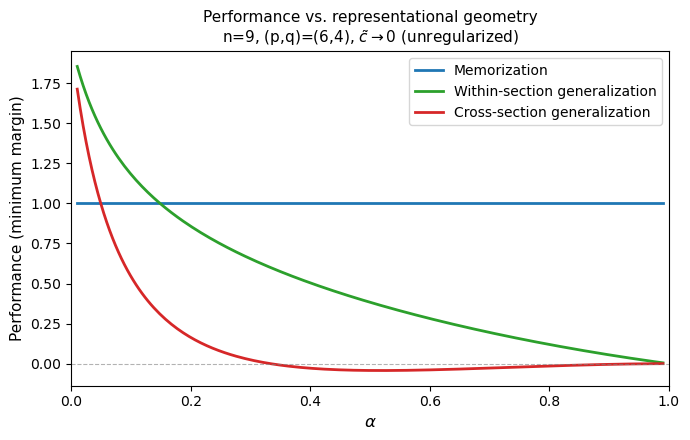

In [70]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b_min_margin.pdf", bbox_inches="tight")

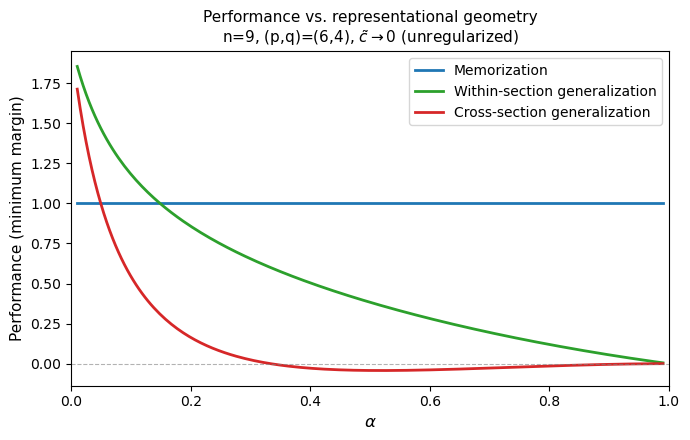

In [68]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b_min_margin.pdf", bbox_inches="tight")

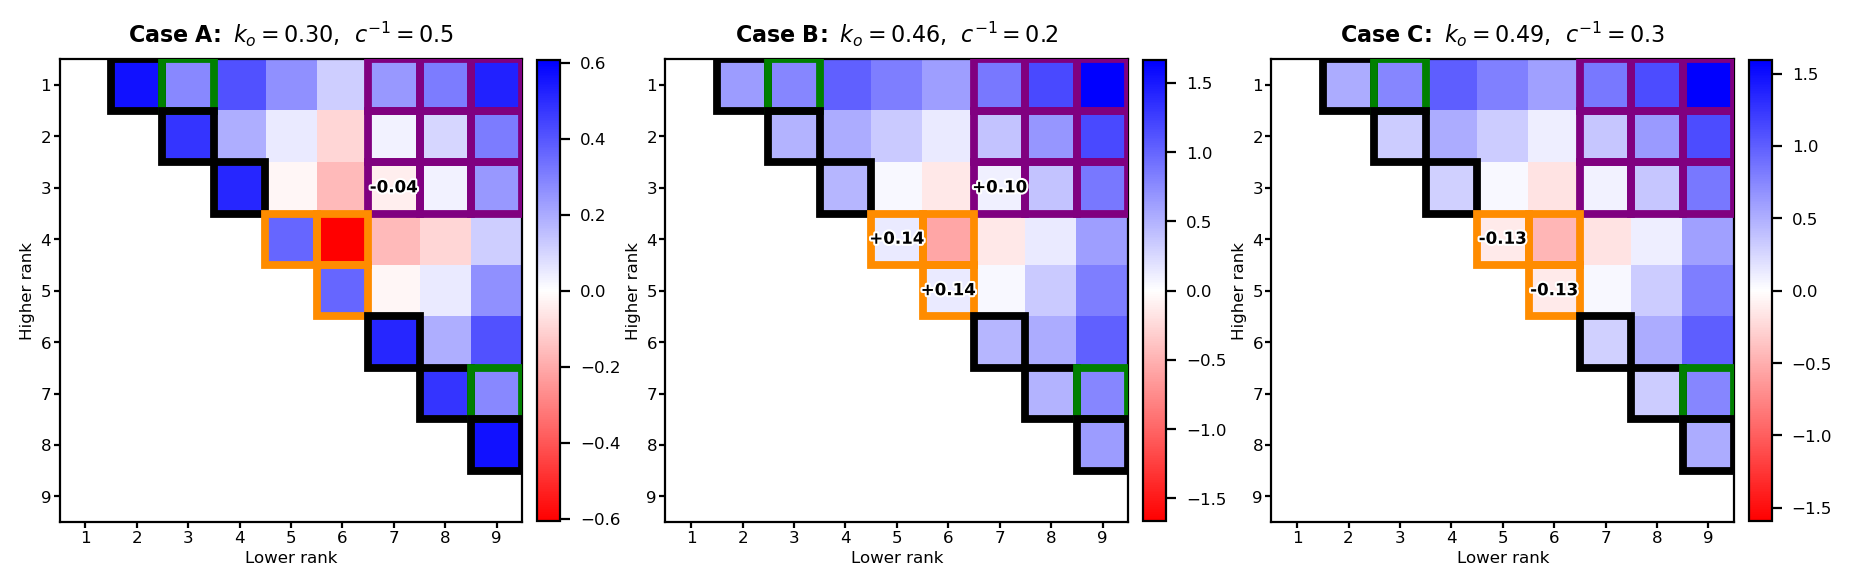

In [50]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from Ranking_exp import Ranking_exp


def _build_matrix(sub: pd.DataFrame, metric: str):
    agg = (
        sub.groupby(["rank_higher", "rank_lower", "seed"])[metric].mean()
        .reset_index()
        .groupby(["rank_higher", "rank_lower"])[metric].mean()
        .reset_index()
    )
    meta = (
        sub.groupby(["rank_higher", "rank_lower"])[
            ["is_train", "is_exception", "within_gen", "across_gen"]
        ]
        .first()
        .reset_index()
    )
    agg = agg.merge(meta, on=["rank_higher", "rank_lower"])
    n = int(agg[["rank_higher", "rank_lower"]].max().max()) + 1
    M                = np.full((n, n), np.nan)
    train_mask       = np.zeros((n, n), dtype=bool)
    exc_mask         = np.zeros((n, n), dtype=bool)
    within_gen_mask  = np.zeros((n, n), dtype=bool)
    across_gen_mask  = np.zeros((n, n), dtype=bool)
    for _, row in agg.iterrows():
        i, j = int(row["rank_higher"]), int(row["rank_lower"])
        M[i, j] = row[metric]
        if row["is_train"] and not row["is_exception"]:
            train_mask[i, j] = True
        elif row["is_exception"]:
            exc_mask[i, j] = True
        elif row["within_gen"]:
            within_gen_mask[i, j] = True
        elif row["across_gen"]:
            across_gen_mask[i, j] = True

    # Keep only the diagonal and upper triangle (i <= j); hide the rest.
    lower = np.tril_indices(n, k=-1)
    M[lower]               = np.nan
    train_mask[lower]      = False
    exc_mask[lower]        = False
    within_gen_mask[lower] = False
    across_gen_mask[lower] = False

    return M, train_mask, exc_mask, within_gen_mask, across_gen_mask


def _draw_matrix(ax, M, train_mask, exc_mask, within_gen_mask, across_gen_mask,
                 *, cmap, vmin, vmax, fmt,
                 tick_labels=None, show_numbers=False,
                 annotate_cells=None, colorbar_label=""):
    n = M.shape[0]
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label(colorbar_label, fontsize=6)
    cb.ax.tick_params(labelsize=6)

    if show_numbers:
        for i in range(n):
            for j in range(n):
                if not np.isnan(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:{fmt}}", ha="center", va="center",
                            fontsize=5, color="black")
    elif annotate_cells:
        for (r1, c1) in annotate_cells:
            r0, c0 = r1 - 1, c1 - 1
            if not np.isnan(M[r0, c0]):
                ax.text(c0, r0, f"{M[r0, c0]:{fmt}}", ha="center", va="center",
                        fontsize=6, color="black", fontweight="bold", zorder=4,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground="white")])

    lw    = 2.8
    inset = 0.00
    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="black", lw=lw, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="darkorange", lw=lw, zorder=3))
            elif within_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="green", lw=lw, zorder=3))
            elif across_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="purple", lw=lw, zorder=3))

    labels = tick_labels if tick_labels is not None else [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Lower rank", fontsize=6, labelpad=2)
    ax.set_ylabel("Higher rank", fontsize=6, labelpad=2)
    ax.tick_params(axis="both", length=2, pad=1)


# ── shared experiment parameters ──────────────────────────────────────
n   = 9
p   = 6
q   = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

# Representative conditions from the phase diagram
# (k_o, c_inv) → c_reg = 1 / (c_inv * delta_s)
conditions = [
    (0.3, 0.50),   # condition 1
    (0.46, 0.2),   # condition 2
    (0.49, 0.30),   # condition 3
]

# ── build one heatmap-DataFrame per condition ─────────────────────────
def build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d):
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)
    rows = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            margin = sim.f_j_k(i + 1, j + 1)
            transverse_pairs = (
                (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
                or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
            )
            is_train = (i == j + 1) or (j == i + 1) #  or transverse_pairs

            # Section membership (0-indexed):
            #   O^(1) = {I_1, ..., I_{q-1}}  ->  indices {0, ..., q-2}
            #   O^(2) = {I_{p+1}, ..., I_n}  ->  indices {p, ..., n-1}
            in_O1_i = i < q - 1
            in_O1_j = j < q - 1
            in_O2_i = i >= p
            in_O2_j = j >= p
            within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
            across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)

            rows.append({
                "phase":        "post",
                "seed":         0,
                "rank_higher":  i,
                "rank_lower":   j,
                "margin":       margin,
                "correct":      1 if margin > 0 else 0,
                "is_train":     is_train,
                "is_exception": transverse_pairs,
                "within_gen":   within_gen,
                "across_gen":   across_gen,
            })
    return pd.DataFrame(rows)


# ── plot: three columns of margin heatmaps ────────────────────────────
with plt.rc_context({"figure.dpi": 200}):
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0))

    # Per-condition margin annotations: 1-indexed (row, col) tuples.
    annotate_cells_map = {
        0: [(3, 7)],
        1: [(3, 7), (4, 5), (5, 6)],
        2: [(4, 5), (5, 6)],
    }

    # Per-condition title prefixes (bolded via mathtext \mathbf).
    title_prefix_map = {
        0: r"$\mathbf{Case\ A\!:}$ ",
        1: r"$\mathbf{Case\ B\!:}$ ",
        2: r"$\mathbf{Case\ C\!:}$ ",
    }

    for idx, (k_o, c_inv) in enumerate(conditions):
        c_reg = 1.0 / (c_inv * delta_s)
        df = build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d)
        sub = df[df["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)

        ax = axes[idx]
        _draw_matrix(
            ax, M_m, tm, em, wgm, agm,
            cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
            show_numbers=False,
            annotate_cells=annotate_cells_map.get(idx, []),
            colorbar_label="",
        )
        ax.set_title(
            f"{title_prefix_map.get(idx, '')}$k_o={k_o:.2f}$,  $c^{{-1}}={c_inv}$",
            fontsize=8, pad=6,
        )

    # fig.suptitle(
    #     f"Figure 4.3a — Representative $f(j,k)$ heatmaps  "
    #     f"(n={n}, p={p}, q={q})",
    #     fontsize=10, y=1.04,
    # )
    plt.tight_layout(pad=0.5, w_pad=0.2)
    plt.show()
    fig.savefig("figure_4_3a.pdf", bbox_inches="tight")

In [ ]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters -------------------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.499, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 10, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = [q - 1, p+1]      # (q-1, p): test generalization margin
train_critical_pair = [q, q + 1]      # (q, q+1): training margin

# ------------------------- sweep -------------------------
breaking_reg_test  = []
breaking_reg_train = []

for k_o in tqdm(k_o_vals, desc='k_o sweep'):

    # -- find smallest c_var where TEST margin flips negative --
    test_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(test_critical_pair[0], test_critical_pair[1]) < 0:
            breaking_reg_test.append(c_var_vals[i])
            test_flag = True
            break
    if not test_flag:
        breaking_reg_test.append(0)

    # -- find smallest c_var where TRAIN margin flips negative --
    train_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(train_critical_pair[0], train_critical_pair[1]) < 0:
            breaking_reg_train.append(c_var_vals[i])
            train_flag = True
            break
    if not train_flag:
        breaking_reg_train.append(0)

# ------------------------- plot -------------------------
train   = np.array(breaking_reg_train)
test    = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    ax.plot(alpha_vals, train, lw=1.0, color='#1f77b4',
            label='Training boundary (memorization)')
    ax.plot(alpha_vals, test,  lw=1.0, color='#ff7f0e',
            label='Test boundary (generalization)')

    ax.fill_between(alpha_vals, overlap, train, alpha=0.12, color='#1f77b4')
    ax.fill_between(alpha_vals, overlap, test,  alpha=0.12, color='#ff7f0e')
    ax.fill_between(alpha_vals, 0, overlap, alpha=0.20, color='#2ca02c',
                    label='Correct on both')

    ax.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax.set_ylabel(r'$c^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax.set_title(
        f'Phase diagram: representational geometry vs. regularization\n'
        f'$n={n}$, $p={p}$, $q={q}$',
        fontsize=6, pad=4
    )
    ax.legend(fontsize=5, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    ax.set_xlim(0.0, 0.40)
    ax.set_ylim(bottom=0)
    ax.grid(False)

    plt.tight_layout(pad=0.5)
    plt.show()
    fig.savefig("figure_4e.pdf", bbox_inches="tight")

Validation passed on 5 sampled k_o values.


k_o sweep (bisect):   0%|          | 0/200 [00:00<?, ?it/s]

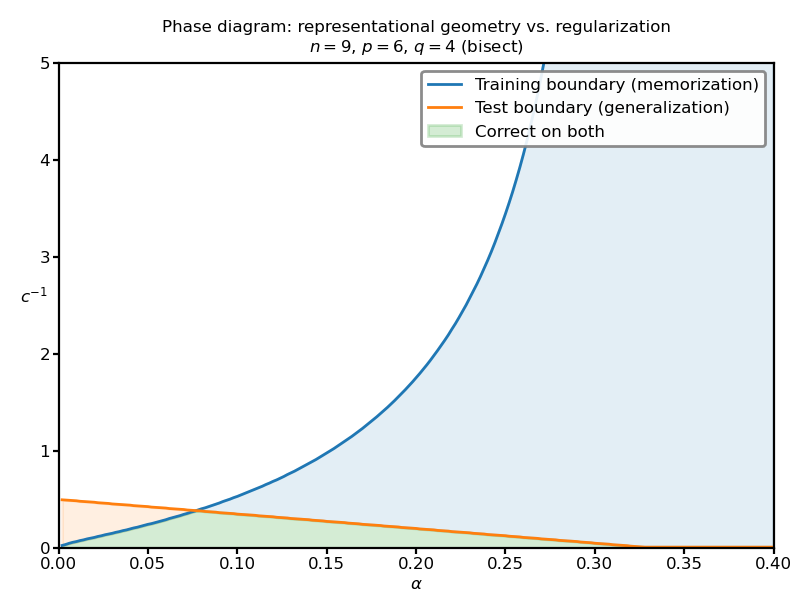

In [67]:
# ---- Tier 1 + Tier 2: binary-search sweep (assumes monotonicity in c_reg) ----
# Builds one Ranking_exp per probe (not per critical-pair); bisects the
# c_var index at which each margin first flips negative.
#
# Before running the full sweep, we validate against the linear scan on a
# small sample of k_o values so we'd catch any non-monotonic cases.

import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters (identical to linear sweep) ------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.4999, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 100, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = (q - 1, p + 1)
train_critical_pair = (q,     q + 1)


# ------------------------- helpers -------------------------------------------
def _make_sim(k_o, cr):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=cr)


def bisect_flip_both(k_o):
    """Return (c_var_test, c_var_train) at first flip, NaN if never flips.

    Uses one bisect per critical pair, reusing the sim at each probed index.
    """
    N = len(c_vals)

    def sim_at(i, _cache={}):
        if i not in _cache:
            _cache[i] = _make_sim(k_o, c_vals[i])
        return _cache[i]

    def first_flip(pair):
        # If the last c_reg (weakest regularization) hasn't flipped, skip.
        if sim_at(N - 1).f_j_k(*pair) >= 0:
            return np.nan
        lo, hi = 0, N - 1
        while lo < hi:
            mid = (lo + hi) // 2
            if sim_at(mid).f_j_k(*pair) < 0:
                hi = mid
            else:
                lo = mid + 1
        return c_var_vals[lo]

    return first_flip(test_critical_pair), first_flip(train_critical_pair)


def linear_flip_both(k_o):
    """Reference linear scan, for validation."""
    ft = None
    fr = None
    for i, cr in enumerate(c_vals):
        sim = _make_sim(k_o, cr)
        if ft is None and sim.f_j_k(*test_critical_pair) < 0:
            ft = c_var_vals[i]
        if fr is None and sim.f_j_k(*train_critical_pair) < 0:
            fr = c_var_vals[i]
        if ft is not None and fr is not None:
            break
    return (ft if ft is not None else np.nan,
            fr if fr is not None else np.nan)


# ------------------------- validation -----------------------------------------
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(k_o_vals), size=5, replace=False)
for si in sample_idx:
    k_o = k_o_vals[si]
    bt, br = bisect_flip_both(k_o)
    lt, lr = linear_flip_both(k_o)
    assert np.isclose(bt, lt, equal_nan=True) and np.isclose(br, lr, equal_nan=True), \
        f"Mismatch at k_o={k_o:.4f}: bisect=({bt},{br}) linear=({lt},{lr})"
print("Validation passed on 5 sampled k_o values.")


# ------------------------- full bisect sweep ---------------------------------
breaking_reg_test  = np.zeros_like(k_o_vals)
breaking_reg_train = np.zeros_like(k_o_vals)

for idx, k_o in enumerate(tqdm(k_o_vals, desc='k_o sweep (bisect)')):
    breaking_reg_test[idx], breaking_reg_train[idx] = bisect_flip_both(k_o)


# ------------------------- plot ----------------------------------------------
train = breaking_reg_train
test  = breaking_reg_test

# For the FILL, treat "never flips" (NaN) as the top of the plot so the
# corresponding region gets shaded all the way up.
# For the LINE, leave NaN in place so matplotlib draws a gap instead of a
# steep descent down to 0.
ylim_top = 5.0
train_fill   = np.where(np.isnan(train), ylim_top, train)
test_fill    = np.where(np.isnan(test),  ylim_top, test)
overlap_fill = np.minimum(train_fill, test_fill)

with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(figsize=(4, 3.0))

    ax.plot(alpha_vals, train, lw=1.0, color='#1f77b4',
            label='Training boundary (memorization)')
    ax.plot(alpha_vals, test,  lw=1.0, color='#ff7f0e',
            label='Test boundary (generalization)')

    # Blue tint where train > test (memorization-only region).
    ax.fill_between(alpha_vals, overlap_fill, train_fill,
                    where=(train_fill > test_fill), interpolate=True,
                    alpha=0.12, color='#1f77b4')
    # Orange tint where test > train (test-only region).
    ax.fill_between(alpha_vals, overlap_fill, test_fill,
                    where=(test_fill > train_fill), interpolate=True,
                    alpha=0.12, color='#ff7f0e')
    ax.fill_between(alpha_vals, 0, overlap_fill, alpha=0.20, color='#2ca02c',
                    label='Correct on both')

    ax.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax.set_ylabel(r'$c^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax.set_title(
        f'Phase diagram: representational geometry vs. regularization\n'
        f'$n={n}$, $p={p}$, $q={q}$ (bisect)',
        fontsize=6, pad=4
    )
    ax.legend(fontsize=6, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    ax.set_xlim(0.0, 0.40)
    ax.set_ylim(0, ylim_top)
    ax.grid(False)

    plt.tight_layout(pad=0.5)
    plt.show()
    fig.savefig("figure_4e_bisect.pdf", bbox_inches="tight")


# Previous Code for Phase Diagram

In [54]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters -------------------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.499, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 10, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = [q - 1, p+1]      # (q-1, p): test generalization margin
train_critical_pair = [q, q + 1]      # (q, q+1): training margin

# ------------------------- sweep -------------------------
breaking_reg_test  = []
breaking_reg_train = []

for k_o in tqdm(k_o_vals, desc='k_o sweep'):

    # -- find smallest c_var where TEST margin flips negative --
    test_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(test_critical_pair[0], test_critical_pair[1]) < 0:
            breaking_reg_test.append(c_var_vals[i])
            test_flag = True
            break
    if not test_flag:
        breaking_reg_test.append(0)

    # -- find smallest c_var where TRAIN margin flips negative --
    train_flag = False
    for i, cr in enumerate(c_vals):
        with contextlib.redirect_stdout(io.StringIO()):
            sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                              p=p, q=q, c_reg=cr)
        if sim.f_j_k(train_critical_pair[0], train_critical_pair[1]) < 0:
            breaking_reg_train.append(c_var_vals[i])
            train_flag = True
            break
    if not train_flag:
        breaking_reg_train.append(0)

# ------------------------- plot -------------------------
train   = np.array(breaking_reg_train)
test    = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    ax.plot(alpha_vals, train, lw=1.0, color='#1f77b4',
            label='Training boundary (memorization)')
    ax.plot(alpha_vals, test,  lw=1.0, color='#ff7f0e',
            label='Test boundary (generalization)')

    ax.fill_between(alpha_vals, overlap, train, alpha=0.12, color='#1f77b4')
    ax.fill_between(alpha_vals, overlap, test,  alpha=0.12, color='#ff7f0e')
    ax.fill_between(alpha_vals, 0, overlap, alpha=0.20, color='#2ca02c',
                    label='Correct on both')

    ax.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax.set_ylabel(r'$c^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax.set_title(
        f'Phase diagram: representational geometry vs. regularization\n'
        f'$n={n}$, $p={p}$, $q={q}$',
        fontsize=6, pad=4
    )
    ax.legend(fontsize=5, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    ax.set_xlim(0.0, 0.40)
    ax.set_ylim(bottom=0)
    ax.grid(False)

    plt.tight_layout(pad=0.5)
    plt.show()
    fig.savefig("figure_4e.pdf", bbox_inches="tight")

k_o sweep:   0%|          | 0/199 [00:00<?, ?it/s]

KeyboardInterrupt: 